# Global imports

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

from joblib import Parallel, delayed
from numpy import random

import anndata as ann
import joblib
import gseapy as gp
import gc
from scipy.stats import kendalltau, ttest_ind
from matplotlib.colors import TwoSlopeNorm
from sklearn.utils import shuffle
import scanpy as sc
from statsmodels.stats.multitest import multipletests
import textwrap
import sys
from heatmap_r import heatmap

In [ ]:
path_dir = '../OverlapAnalysis_thor_pmi_adj/'
prefix_ad = path_dir+'AD/Rosmap/'
prefix_pd = path_dir+ 'PD/Kam/'
prefix_sea = path_dir+'AD/Sea/'
prefix_sm = path_dir+'PD/Sm/'
fp = '../NeuroOverlap/Jan_15/'

In [ ]:
deg_path = '../NeuroOverlap/DGE/'

In [ ]:
def cosine_similarity(vecA, vecB):
    return np.dot(vecA, vecB)/(np.linalg.norm(vecA, ord=2) * np.linalg.norm(vecB, ord=2))

In [ ]:
ct_map_pd = {'Astrocyte':'Ast', 
            'Endothelial':'End', 
            'Ependyma':'Epen',
            'Excitatory neuron':'Ex', 
            'Inhibitory neuron':'In', 
            'Macrophage':'Macro',
            'Microglia':'Mic', 
            'OPC':'Opc', 
            'Oligodendrocyte':'Oli', 
            'CALB1' : 'Calb1',
            'SOX6' : 'Sox6',
        }

In [ ]:
ct_map_sea = {'vip': 'Vip',
            'l5_it': 'L5_it',
            'l4_it': 'L4_it',
            'oligo': 'Oli',
            'micro': 'Mic',
            'opc': 'Opc',
            'endo': 'End',
            'astro': 'Ast',
            'pvalb':'Pvalb',
            'sst':'Sst',
            'sncg':'Sncg'
            }

In [ ]:
ct_map_sm = {'Oligodendrocytes': 'Oli',
            'Excitatory neuron': 'Ex',
            'Inhibitory neuron': 'In',
            'Astrocyte': 'Ast',
            'Endothelial cells': 'End',
            'Microglia': 'Mic',
            'OPC': 'Opc',
            'Ependymal': 'Epen',
            'Pericytes': 'Per',
            'GABA' :'Gaba'}

In [ ]:
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'

# MAST

## Utils

In [ ]:
mast_path = '/Users/anwesha/Library/CloudStorage/OneDrive-McGillUniversity/PHD/Research/DGE/MAST/'

In [ ]:
# perform GSEA for each component in the model
def do_gsea_MAST(celltype, gene_set_list, weight_df, seed = None, do_shuffle=False):
    print(celltype.upper())
    loadings_df = weight_df[(weight_df.cell_type == celltype)
                            &(weight_df.fdr<0.05)][['logFC', 'gene']]
    print(f'cell type {celltype} has {loadings_df.gene.unique().shape[0]} genes')
    gsea_terms_tmp_comp = pd.DataFrame()
    # perform GSEA using multiple gene set databases
    for gene_set in gene_set_list:
        loadings = loadings_df['logFC'].values
        gene_symbol = loadings_df['gene'].values
        gene_symbol = gene_symbol[loadings!=0]
        loadings = loadings[loadings!=0]
        if do_shuffle:
            loadings = shuffle(loadings, random_state=seed)
        ranked_genes = pd.DataFrame(data={'genes':gene_symbol, 
                                        'logFC': loadings})
        pre_res = None
        try:
            pre_res = gp.prerank(rnk=ranked_genes,
                            gene_sets=gene_set,
                            processes=4,
                            min_size=5, 
                            # max_size=1000,
                            no_plot=True,
                            permutation_num=1000,
                            outdir=None,
                            seed=1)
        except Exception:
            print(f'GSEA Error: No enriched gene modules found in celltype {celltype}')
        
        if pre_res:
            df = pre_res.res2d
            df['gene_set_source'] = gene_set
            df = df[df['FDR q-val']<0.05]
            df = df[~df['NOM p-val'].isna()]
            df['cell_type'] = celltype
            df = df.sort_values('NES', ascending=False)
            if not df.empty:
                gsea_terms_tmp_comp = pd.concat((gsea_terms_tmp_comp, df), axis=0)
    return gsea_terms_tmp_comp

In [ ]:
gene_set_list = ['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'GO_Cellular_Component_2023']

## Rosmap Kamath

##### Do DEG

In [ ]:
deg_ros = pd.read_csv(mast_path + 'AD_Rosmap.csv', index_col = 0)
deg_ros = deg_ros[deg_ros.fdr<0.05].dropna(subset='logFC')
deg_kam = pd.read_csv(mast_path + 'PD_Kamath.csv', index_col = 0)
deg_kam = deg_kam[deg_kam.fdr<0.05].dropna(subset='logFC')

In [ ]:
merged_kr_df = deg_ros.merge(deg_kam, on = 'gene', how = 'inner', suffixes=['_ros', '_kam'])
merged_kr_df.head()

,gene,logFC_ros,pval_ros,fdr_ros,cell_type_ros,logFC_kam,pval_kam,fdr_kam,cell_type_kam
0,LINGO1,0.030734,1.556582e-130,2.646812e-126,Ex,-0.019947,9.164756e-23,2.848246e-22,CALB1
1,LINGO1,0.030734,1.556582e-130,2.646812e-126,Ex,-0.009025,5.384576e-05,1.173050e-04,Astrocyte
2,LINGO1,0.030734,1.556582e-130,2.646812e-126,Ex,-0.003125,1.851586e-04,5.210023e-04,Endothelial
3,LINGO1,0.030734,1.556582e-130,2.646812e-126,Ex,0.019822,2.188933e-03,3.417682e-03,Microglia
4,LINGO1,0.030734,1.556582e-130,2.646812e-126,Ex,-0.006331,4.592316e-23,5.347050e-22,OPC


In [ ]:
merged_kr_df = merged_kr_df[merged_kr_df.cell_type_kam!='Macrophage']
_df = merged_kr_df[(merged_kr_df.cell_type_kam=='Astrocyte') & (merged_kr_df.cell_type_ros=='Ex')]

In [ ]:
print('kendall: ', kendalltau(_df.logFC_kam, _df.logFC_ros))
print('cosine: ', cosine_similarity(_df.logFC_kam, _df.logFC_ros))


kendall:  SignificanceResult(statistic=0.060895145298185, pvalue=2.000681172668001e-15)
cosine:  0.20883377300774075


In [ ]:
def kendalltau_stats(_ser):
    r = kendalltau(_ser['logFC_kam'], _ser['logFC_ros'])
    return pd.Series({'corr': r.statistic, 'pval': r.pvalue, 'nover': _ser.shape[0]})


In [ ]:
corr_df = (merged_kr_df.groupby(['cell_type_ros', 'cell_type_kam'], observed = True).apply(kendalltau_stats)).reset_index()
corr_df.dropna(subset = 'pval', inplace = True)
_, fdr, _, _= multipletests(corr_df["pval"], method="fdr_bh")
corr_df['fdr'] = fdr
corr_df = corr_df[corr_df.fdr<0.05]
corr_df.head(2)


,cell_type_ros,cell_type_kam,corr,pval,nover,fdr
2,Ast,Endothelial,0.154581,1.057108e-02,125.0,3.226961e-02
10,Ex,Astrocyte,0.060895,2.000681e-15,7562.0,1.160395e-14


In [ ]:
corr_df['cell_type_kam'] = corr_df.cell_type_kam.replace(ct_map_pd)

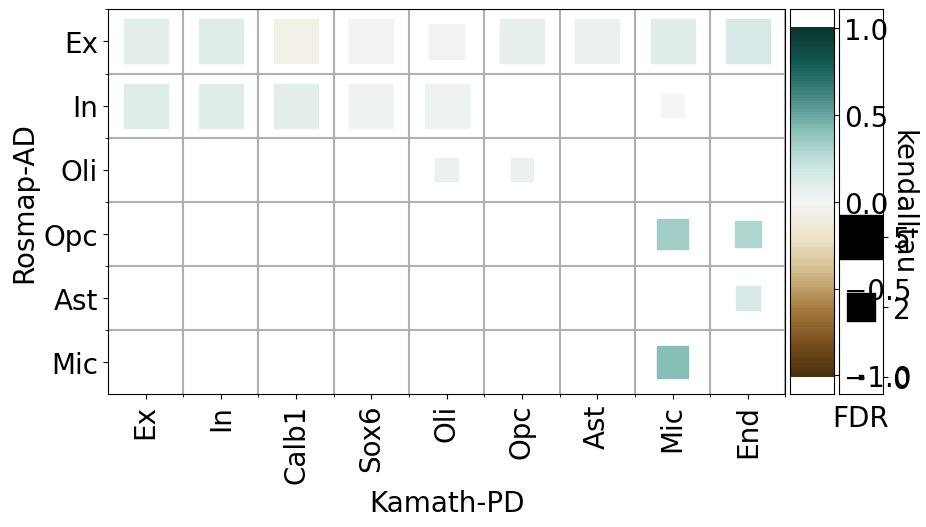

In [ ]:
corr_df_ = corr_df[corr_df.cell_type_kam!='Epen']
xlabel = corr_df_['cell_type_kam']
ylabel = corr_df_['cell_type_ros']
size_labels = [0, 2, 5]
fontsize = 20

y_order = [ 'Ex', 'In', 'Oli', 'Opc', 'Ast', 'Mic' ]
x_order = ['Ex', 'In', 'Calb1', 'Sox6', 'Oli', 'Opc', 'Ast', 'Mic', 'End']


figsize = (10,5)
f = plt.figure(figsize=figsize)
ax, ax1, ax2, ss = heatmap(
    x=xlabel, 
    y=ylabel, 
    size_scale=1000,
    size=-np.log10(corr_df_['fdr']),
    size_range = (size_labels[0], size_labels[-1]),
    color=corr_df_[f'corr'].fillna(0),
    color_range=(0,-1, 1),
    palette=palette,
    fontsize = fontsize,
    x_tick_rotation = 90,
    num_size_label=6,
    m_color='k',
    x_order = x_order if x_order else xlabel.sort_values().unique(),
    y_order = y_order[::-1] if y_order else ylabel.sort_values().unique()[::-1],
    size_labels = size_labels,
    facecolor = 'white',
)

ax.set_ylabel(f'Rosmap-AD', fontsize=fontsize)
ax.set_xlabel(f'Kamath-PD', fontsize=fontsize)

ax.grid(linewidth=1.5, which='minor')
ax1.set_ylabel(f'kendalltau', fontsize = fontsize, rotation=-90)
ax1.yaxis.set_label_position("right")
_ = ax2.set_yticklabels(size_labels, rotation=0, fontsize = fontsize)
_ = ax2.set_xlabel('FDR', fontsize=fontsize)
ax2.patch.set_alpha(0)
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()): label.set_fontsize(fontsize)
# f.savefig(fp+'RK_DEGene_MAST.svg', bbox_inches='tight', )

##### Do GSEA

In [ ]:
gsea_df_ros = pd.read_csv(mast_path + 'AD_Rosmap_GSEA.csv', index_col = 0)
gsea_df_ros=gsea_df_ros[gsea_df_ros['FDR q-val']<0.1]
gsea_df_kam = pd.read_csv(mast_path + 'PD_Kamath_GSEA.csv', index_col = 0)
gsea_df_kam=gsea_df_kam[gsea_df_kam['FDR q-val']<0.1]


In [ ]:
gsea_df = gsea_df_ros.merge(gsea_df_kam, on = 'Term', how = 'inner', suffixes=('_ad', '_pd'))
gsea_df[gsea_df.gene_set_source_pd=='GO_Biological_Process_2023']

,Name_ad,Term,ES_ad,NES_ad,NOM p-val_ad,FDR q-val_ad,FWER p-val_ad,Tag %_ad,Gene %_ad,Lead_genes_ad,...,ES_pd,NES_pd,NOM p-val_pd,FDR q-val_pd,FWER p-val_pd,Tag %_pd,Gene %_pd,Lead_genes_pd,gene_set_source_pd,cell_type_pd
0,prerank,Cytoplasmic Translation (GO:0002181),0.709280,2.68765,0.0,0.000000,0.000,70/87,19.39%,RPL31;RPL32;RPL38;RPS24;RPL23A;RPL34;RPS25;RPL...,...,0.799660,3.013859,0.0,0.013950,0.014,70/86,12.91%,RPL8;RPS15;RPL19;RPL32;RPS19;RPLP1;RPL13;RPL18...,GO_Biological_Process_2023,Microglia
1,prerank,Cytoplasmic Translation (GO:0002181),0.709280,2.68765,0.0,0.000000,0.000,70/87,19.39%,RPL31;RPL32;RPL38;RPS24;RPL23A;RPL34;RPS25;RPL...,...,0.758534,2.320309,0.0,0.004068,0.004,65/86,13.67%,RPL37A;RPLP1;RPL34;RPS24;RPS25;RPL19;RPLP2;RPL...,GO_Biological_Process_2023,OPC
2,prerank,Cytoplasmic Translation (GO:0002181),0.709280,2.68765,0.0,0.000000,0.000,70/87,19.39%,RPL31;RPL32;RPL38;RPS24;RPL23A;RPL34;RPS25;RPL...,...,-0.518533,-2.391035,0.0,0.058661,0.085,62/86,30.04%,RPS27;RPL34;RPS8;RPLP1;RPL37;RPL12;RPS28;RPL35...,GO_Biological_Process_2023,Inhibitory neuron
3,prerank,Defense Response To Gram-negative Bacterium (G...,0.688389,2.35490,0.0,0.082196,0.204,20/42,14.29%,DMBT1;TREM2;TLR4;GSDMD;DEFA5;LYZ;RNASE6;PYCARD...,...,-0.917056,-3.037243,0.0,0.047000,0.037,1/42,0.01%,LYPD8,GO_Biological_Process_2023,Excitatory neuron


In [ ]:
gsea_df = gsea_df.drop(gsea_df[gsea_df.cell_type_pd=='Macrophage'].index)

In [ ]:
gsea_df['cell_type_ad_pd'] = gsea_df['cell_type_ad'].astype(str)+' ' + gsea_df['cell_type_pd'].replace(ct_map_pd).astype(str)

In [ ]:
gsea_df['Term'] = gsea_df['Term'].map(lambda x: x.rsplit(' (GO', 1)[0])

/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_27133/2532007152.py:4: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  _ = sns.scatterplot(gsea_df.sort_values('gene ontology'),
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_27133/2532007152.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  _ = ax.set_yticklabels([textwrap.fill(w.get_text(), width=30) for w in ax.get_yticklabels()],)# ha='right', va='top')


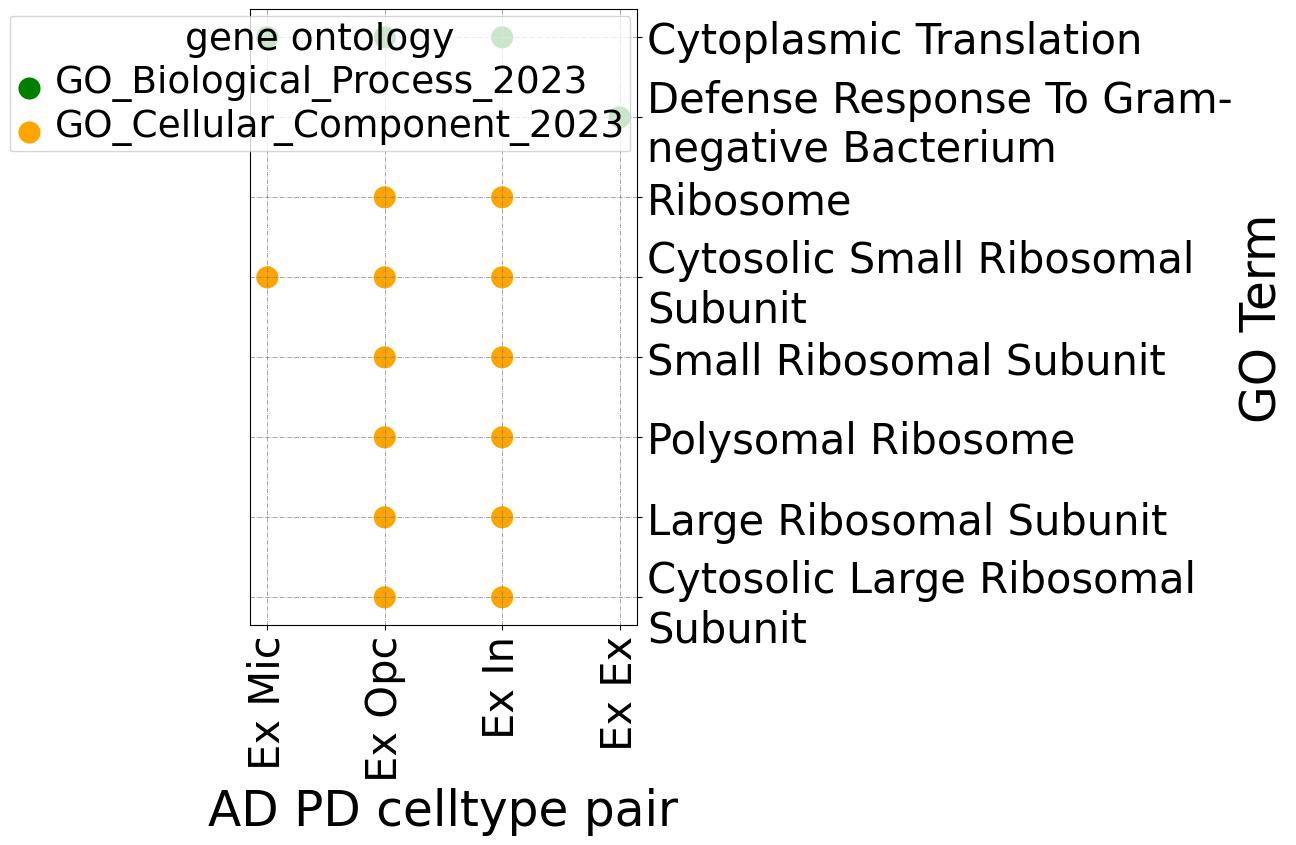

In [ ]:
gsea_df.rename(columns={'gene_set_source_pd':'gene ontology'}, inplace=True)
f, ax = plt.subplots(figsize=(5, 8))
fs = 35
_ = sns.scatterplot(gsea_df.sort_values('gene ontology'), 
hue = 'gene ontology', y = 'Term', x = 'cell_type_ad_pd', 
color = 'indigo', s =300, palette=['green', 'orange', 'blue'], ax=ax)
ax.tick_params(axis='x', rotation=90)
ax.yaxis.set_label_position("right")
ax.yaxis.set_ticks_position("right")
_ = ax.set_yticklabels([textwrap.fill(w.get_text(), width=30) for w in ax.get_yticklabels()],)# ha='right', va='top')
ax.tick_params(labelsize=fs-5)
_ = ax.set_xlabel('AD PD celltype pair', fontsize=fs)
_ = ax.set_ylabel('GO Term', fontsize=fs)

# ax.legend(labels=['Total genes', 'Robust genes'], title='BS genes')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_fontsize(fs - 8)
legend.get_title().set_fontsize(fs - 8)
ax.grid(color = 'gray', linestyle = '-.', linewidth = 0.5)

## Seattle Smajic

##### Do DEG

In [ ]:
deg_sea = pd.read_csv(mast_path + 'AD_SEAAD.csv', index_col = 0)
deg_sea = deg_sea[deg_sea.fdr<0.05].dropna(subset='logFC')
deg_sm = pd.read_csv(mast_path + 'PD_Smajic.csv', index_col = 0)
deg_sm = deg_sm[deg_sm.fdr<0.05].dropna(subset='logFC')


In [ ]:
merged_ss_df = deg_sea.merge(deg_sm, on = 'gene', how = 'inner', suffixes=['_sea', '_sm'])
merged_ss_df.head()

,gene,logFC_sea,pval_sea,fdr_sea,cell_type_sea,logFC_sm,pval_sm,fdr_sm,cell_type_sm
0,ARL17B,0.047006,2.665544e-139,4.086012e-135,sncg,-0.005041,5.635271e-27,2.010761e-25,Oligodendrocytes
1,ARL17B,0.047006,2.665544e-139,4.086012e-135,sncg,-0.001981,6.069019e-03,3.306549e-02,Excitatory neuron
2,ARL17B,0.047006,2.665544e-139,4.086012e-135,sncg,-0.066461,1.456210e-06,1.850764e-05,Astrocyte
3,ARL17B,0.047006,2.665544e-139,4.086012e-135,sncg,0.083148,4.616268e-06,1.808627e-04,Inhibitory neuron
4,ARL17B,0.047006,2.665544e-139,4.086012e-135,sncg,-0.119500,2.602030e-07,1.141777e-04,GABA


In [ ]:
merged_ss_df = merged_ss_df[merged_ss_df.cell_type_sm!='Ependymal']
_df = merged_ss_df[(merged_ss_df.cell_type_sm=='Astrocyte') & (merged_ss_df.cell_type_sea=='pvalb')]


In [ ]:
print('kendall: ', kendalltau(_df.logFC_sm, _df.logFC_sea))
print('cosine: ', cosine_similarity(_df.logFC_sm, _df.logFC_sea))


kendall:  SignificanceResult(statistic=0.023840685147080952, pvalue=0.009318988909398467)
cosine:  0.23353956087487668


In [ ]:
def kendalltau_stats(_ser):
    r = kendalltau(_ser['logFC_sm'], _ser['logFC_sea'])
    return pd.Series({'corr': r.statistic, 'pval': r.pvalue, 'nover': _ser.shape[0]})


In [ ]:
corr_df = (merged_ss_df.groupby(['cell_type_sea', 'cell_type_sm'], observed = True).apply(kendalltau_stats)).reset_index()
corr_df.dropna(subset = 'pval', inplace = True)
_, fdr, _, _= multipletests(corr_df["pval"], method="fdr_bh")
corr_df['fdr'] = fdr
corr_df = corr_df[corr_df.fdr<0.05]
corr_df.head(2)


,cell_type_sea,cell_type_sm,corr,pval,nover,fdr
0,astro,Astrocyte,0.086788,1.005187e-20,5146.0,2.940172e-19
3,astro,Endothelial cells,-0.134646,1.290436e-02,155.0,2.960411e-02


In [ ]:
corr_df['cell_type_sm'] = corr_df.cell_type_sm.replace(ct_map_sm)
corr_df['cell_type_sea'] = corr_df.cell_type_sea.replace(ct_map_sea)

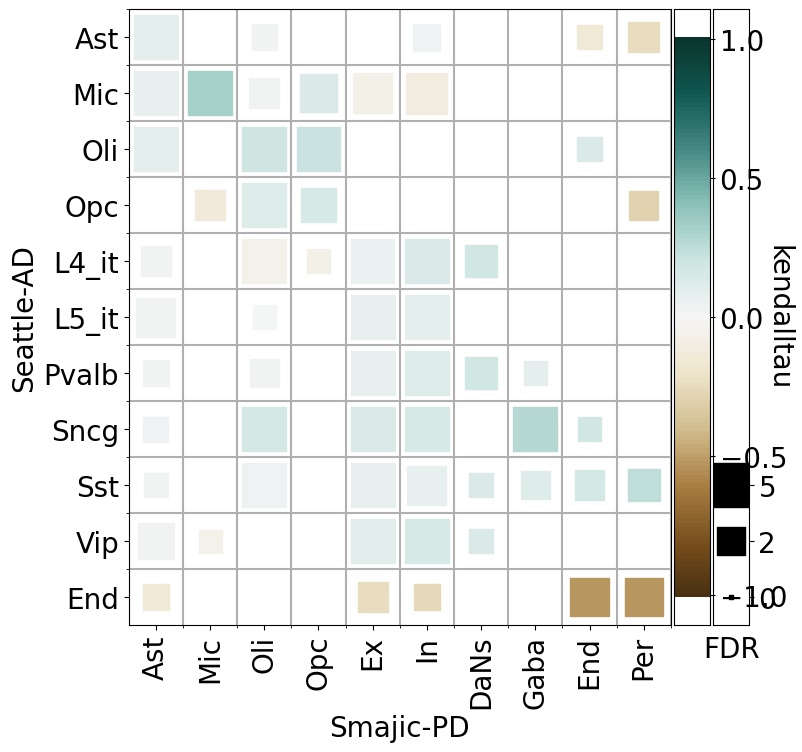

In [ ]:
corr_df_ = corr_df[corr_df.cell_type_sm!='Epen']
xlabel = corr_df_['cell_type_sm']
ylabel = corr_df_['cell_type_sea']
size_labels = [0, 2, 5]
fontsize = 20

x_order = ['Ast', 'Mic', 'Oli', 'Opc', 'Ex', 'In', 'DaNs',  'Gaba', 'End', 'Per', ]
y_order = ['Ast','Mic', 'Oli', 'Opc', 'L4_it', 'L5_it', 'Pvalb', 'Sncg', 'Sst', 'Vip',  'End', ]


figsize = (8,8)
f = plt.figure(figsize=figsize)
ax, ax1, ax2, ss = heatmap(
    x=xlabel, 
    y=ylabel, 
    size_scale=1000,
    size=-np.log10(corr_df_['fdr']),
    size_range = (size_labels[0], size_labels[-1]),
    color=corr_df_[f'corr'].fillna(0),
    color_range=(0,-1, 1),
    palette=palette,
    fontsize = fontsize,
    x_tick_rotation = 90,
    num_size_label=6,
    m_color='k',
    x_order = x_order if x_order else xlabel.sort_values().unique(),
    y_order = y_order[::-1] if y_order else ylabel.sort_values().unique()[::-1],
    size_labels = size_labels,
    facecolor = 'white',
)

ax.set_ylabel(f'Seattle-AD', fontsize=fontsize)
ax.set_xlabel(f'Smajic-PD', fontsize=fontsize)

ax.grid(linewidth=1.5, which='minor')
ax1.set_ylabel(f'kendalltau', fontsize = fontsize, rotation=-90)
ax1.yaxis.set_label_position("right")
_ = ax2.set_yticklabels(size_labels, rotation=0, fontsize = fontsize)
_ = ax2.set_xlabel('FDR', fontsize=fontsize)
ax2.patch.set_alpha(0)
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()): label.set_fontsize(fontsize)
# f.savefig(fp+'SS_DEGene_MAST.svg', bbox_inches='tight', )

In [ ]:
ttest_ind(plsr_corr.kendalltau_corr.values.ravel(), corr_df_['corr'].dropna().values.ravel(), equal_var=False)

Ttest_indResult(statistic=-2.3043584122509215, pvalue=0.024083160408432912)

##### Do GSEA

In [ ]:
gsea_df_sea = pd.read_csv(mast_path + 'AD_SEAAD_GSEA.csv', index_col = 0)
gsea_df_sea=gsea_df_sea[gsea_df_sea['FDR q-val']<0.1]
gsea_df_sm = pd.read_csv(mast_path + 'PD_Smajic_GSEA.csv', index_col = 0)
gsea_df_sm=gsea_df_sm[gsea_df_sm['FDR q-val']<0.1]


In [ ]:
gsea_df = gsea_df_sea.merge(gsea_df_sm, on = 'Term', how = 'inner', suffixes=('_ad', '_pd'))
gsea_df[gsea_df.gene_set_source_pd=='GO_Biological_Process_2023'].Term.unique()

array([], dtype=object)

In [ ]:
gsea_df['cell_type_ad_pd'] = gsea_df['cell_type_ad'].replace(ct_map_sea).astype(str)+' ' + gsea_df['cell_type_pd'].replace(ct_map_sm).astype(str)

In [ ]:
gsea_df['Term'] = gsea_df['Term'].map(lambda x: x.rsplit(' (GO', 1)[0])

/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_27133/842784266.py:4: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  _ = sns.scatterplot(gsea_df.sort_values('gene ontology'), hue = 'gene ontology', y = 'Term', x = 'cell_type_ad_pd', color = 'indigo', s =300, palette=['green', 'orange', 'blue'], ax=ax)
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_27133/842784266.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  _ = ax.set_yticklabels([textwrap.fill(w.get_text(), width=30) for w in ax.get_yticklabels()],)# ha='right', va='top')


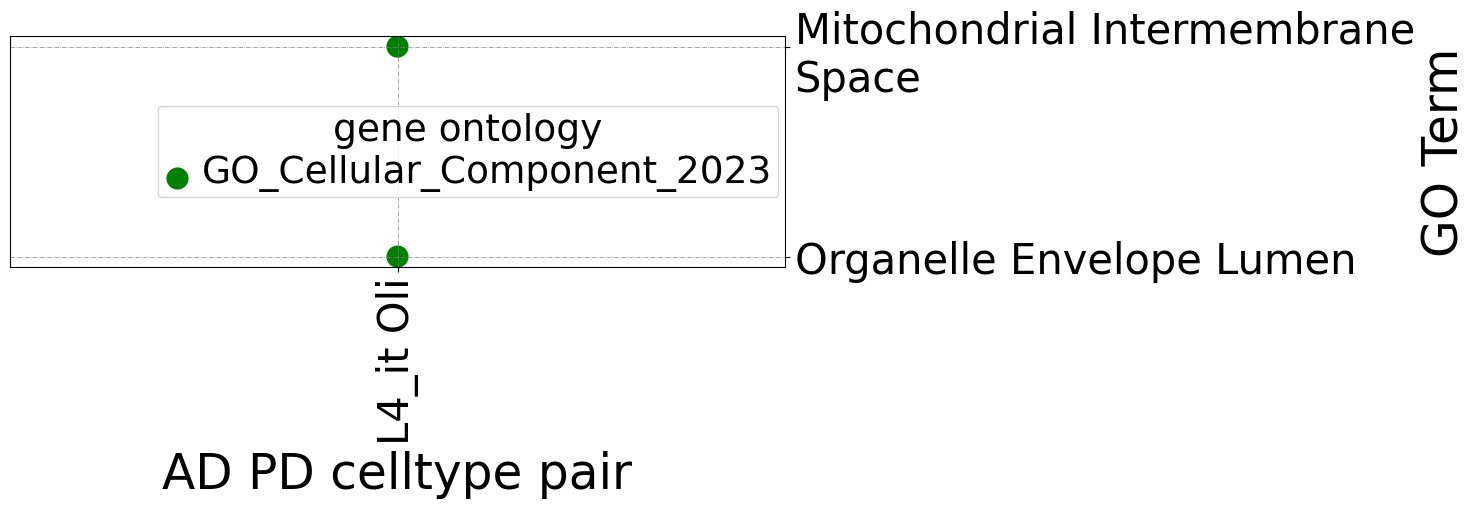

In [ ]:
gsea_df.rename(columns={'gene_set_source_pd':'gene ontology'}, inplace=True)
f, ax = plt.subplots(figsize=(10, 3))
fs = 35
_ = sns.scatterplot(gsea_df.sort_values('gene ontology'), hue = 'gene ontology', y = 'Term', x = 'cell_type_ad_pd', color = 'indigo', s =300, palette=['green', 'orange', 'blue'], ax=ax)
ax.tick_params(axis='x', rotation=90)
ax.yaxis.set_label_position("right")
ax.yaxis.set_ticks_position("right")
_ = ax.set_yticklabels([textwrap.fill(w.get_text(), width=30) for w in ax.get_yticklabels()],)# ha='right', va='top')
ax.tick_params(labelsize=fs-5)
_ = ax.set_xlabel('AD PD celltype pair', fontsize=fs)
_ = ax.set_ylabel('GO Term', fontsize=fs)

# ax.legend(labels=['Total genes', 'Robust genes'], title='BS genes')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.setp(ax.get_legend().get_texts(), fontsize=fs-8) # for legend text
_ = plt.setp(ax.get_legend().get_title(), fontsize=fs-8)
plt.grid(color = 'gray', linestyle = '-.', linewidth = 0.5)